# 10. 최종 모델 종합 평가
## Final Model Evaluation and Robustness Analysis

## 프로젝트: 반도체 수율 예측 (Semiconductor Yield Prediction)

### 분석 목적

본 프로젝트에서는 SECOM 반도체 제조 데이터를 이용하여
Pass/Fail 불량 예측 모델을 단계적으로 구축하였다.

지금까지 다음 실험을 수행하였다.

1. Dummy Classifier를 이용한 기준 성능 확인
2. Logistic Regression Baseline 구축
3. SMOTE 1:1을 이용한 클래스 불균형 처리
4. Mutual Information 기반 Feature Selection
5. Base XGBoost 적용
6. `scale_pos_weight` 적용 XGBoost
7. Decision Threshold Optimization
8. XGBoost Hyperparameter Tuning

본 Notebook에서는 각 실험 결과를 종합적으로 비교하고
Fail 검출 목적에 적합한 최종 모델 후보를 선정한다.

### 주요 평가 기준

- Precision
- Recall
- F1-score
- F2-score
- Average Precision (AP)
- ROC-AUC
- False Negative
- False Positive
- True Positive

특히 반도체 불량 예측에서는 단순 Accuracy보다
실제 Fail을 얼마나 검출하는지와 False Negative를 얼마나 줄이는지를
중요하게 평가한다.

다만 Fail 검출률을 지나치게 높이는 과정에서
False Positive가 크게 증가할 수 있으므로
불량 미검출과 정상 샘플 오탐 사이의 Trade-off를 함께 분석한다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn import set_config
from sklearn.base import (
    BaseEstimator,
    TransformerMixin,
    clone
)

from sklearn.model_selection import (
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_val_predict
)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve
)

from xgboost import XGBClassifier

set_config(display="text")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

## 1. 전체 실험 결과 통합

01~09 단계에서 동일한 고정 Train/Test Split을 이용하여 얻은
모델 성능을 하나의 표로 정리한다.

본 프로젝트에서는 여러 실험 단계에서 동일한 Test Split의 성능을
반복적으로 확인하였으므로 이를 완전히 독립적인
Untouched Final Test Set이라고 표현하지 않는다.

따라서 본 Notebook에서는 해당 데이터를
**Fixed Evaluation Split**으로 표현한다.

이 결과는 각 모델의 실험 진행 방향과 Trade-off를 비교하기 위한
기준으로 사용한다.

In [2]:
fixed_split_results = pd.DataFrame([
    {
        "Model": "Dummy Classifier",
        "Stage": "04 Baseline",
        "Threshold": np.nan,
        "Accuracy": 0.9331,
        "Precision": 0.0000,
        "Recall": 0.0000,
        "F1": 0.0000,
        "F2": 0.0000,
        "AP": 0.0669,
        "ROC-AUC": 0.5000,
        "TN": 293,
        "FP": 0,
        "FN": 21,
        "TP": 0
    },

    {
        "Model": "Logistic Regression",
        "Stage": "04 Baseline",
        "Threshold": 0.5,
        "Accuracy": 0.8758,
        "Precision": 0.1250,
        "Recall": 0.1429,
        "F1": 0.1333,
        "F2": 0.1389,
        "AP": 0.1190,
        "ROC-AUC": 0.6205,
        "TN": 272,
        "FP": 21,
        "FN": 18,
        "TP": 3
    },

    {
        "Model": "Logistic + SMOTE (1:1)",
        "Stage": "05 SMOTE",
        "Threshold": 0.5,
        "Accuracy": 0.8280,
        "Precision": 0.0769,
        "Recall": 0.1429,
        "F1": 0.1000,
        "F2": 0.1220,
        "AP": 0.1187,
        "ROC-AUC": 0.6166,
        "TN": 257,
        "FP": 36,
        "FN": 18,
        "TP": 3
    },

    {
        "Model": "Logistic + MI (All 442)",
        "Stage": "06 Feature Selection",
        "Threshold": 0.5,
        "Accuracy": 0.8758,
        "Precision": 0.1250,
        "Recall": 0.1429,
        "F1": 0.1333,
        "F2": 0.1389,
        "AP": 0.1190,
        "ROC-AUC": 0.6205,
        "TN": 272,
        "FP": 21,
        "FN": 18,
        "TP": 3
    },

    {
        "Model": "Base XGBoost",
        "Stage": "07 XGBoost",
        "Threshold": 0.5,
        "Accuracy": 0.9299,
        "Precision": 0.0000,
        "Recall": 0.0000,
        "F1": 0.0000,
        "F2": 0.0000,
        "AP": 0.1881,
        "ROC-AUC": 0.7444,
        "TN": 292,
        "FP": 1,
        "FN": 21,
        "TP": 0
    },

    {
        "Model": "Weighted XGBoost",
        "Stage": "07 XGBoost",
        "Threshold": 0.5,
        "Accuracy": 0.9299,
        "Precision": 0.0000,
        "Recall": 0.0000,
        "F1": 0.0000,
        "F2": 0.0000,
        "AP": 0.1562,
        "ROC-AUC": 0.7065,
        "TN": 292,
        "FP": 1,
        "FN": 21,
        "TP": 0
    },

    {
        "Model": "Base XGBoost + Optimized Threshold",
        "Stage": "08 Threshold Optimization",
        "Threshold": 0.008612,
        "Accuracy": 0.8217,
        "Precision": 0.1818,
        "Recall": 0.4762,
        "F1": 0.2632,
        "F2": 0.3597,
        "AP": 0.1881,
        "ROC-AUC": 0.7444,
        "TN": 248,
        "FP": 45,
        "FN": 11,
        "TP": 10
    },

    {
        "Model": "Tuned XGBoost + Optimized Threshold",
        "Stage": "09 Hyperparameter Tuning",
        "Threshold": 0.0742,
        "Accuracy": 0.6401,
        "Precision": 0.1102,
        "Recall": 0.6190,
        "F1": 0.1871,
        "F2": 0.3218,
        "AP": 0.1891,
        "ROC-AUC": 0.6815,
        "TN": 188,
        "FP": 105,
        "FN": 8,
        "TP": 13
    }
])

fixed_split_results.round(4)

,Model,Stage,Threshold,Accuracy,Precision,Recall,F1,F2,AP,ROC-AUC,TN,FP,FN,TP
0,Dummy Classifier,04 Baseline,NaN,0.9331,0.0000,0.0000,0.0000,0.0000,0.0669,0.5000,293,0,21,0
1,Logistic Regression,04 Baseline,0.5000,0.8758,0.1250,0.1429,0.1333,0.1389,0.1190,0.6205,272,21,18,3
2,Logistic + SMOTE (1:1),05 SMOTE,0.5000,0.8280,0.0769,0.1429,0.1000,0.1220,0.1187,0.6166,257,36,18,3
3,Logistic + MI (All 442),06 Feature Selection,0.5000,0.8758,0.1250,0.1429,0.1333,0.1389,0.1190,0.6205,272,21,18,3
4,Base XGBoost,07 XGBoost,0.5000,0.9299,0.0000,0.0000,0.0000,0.0000,0.1881,0.7444,292,1,21,0
5,Weighted XGBoost,07 XGBoost,0.5000,0.9299,0.0000,0.0000,0.0000,0.0000,0.1562,0.7065,292,1,21,0
6,Base XGBoost + Optimized Threshold,08 Threshold Optimization,0.0086,0.8217,0.1818,0.4762,0.2632,0.3597,0.1881,0.7444,248,45,11,10
7,Tuned XGBoost + Optimized Threshold,09 Hyperparameter Tuning,0.0742,0.6401,0.1102,0.6190,0.1871,0.3218,0.1891,0.6815,188,105,8,13


In [3]:
fixed_split_results["Total"] = (
    fixed_split_results["TN"]
    + fixed_split_results["FP"]
    + fixed_split_results["FN"]
    + fixed_split_results["TP"]
)

print(
    fixed_split_results[
        ["Model", "Total"]
    ]
)

assert (
    fixed_split_results["Total"] == 314
).all()

print(
    "\nAll confusion matrices contain 314 test samples."
)

                                 Model  Total
0                     Dummy Classifier    314
1                  Logistic Regression    314
2               Logistic + SMOTE (1:1)    314
3              Logistic + MI (All 442)    314
4                         Base XGBoost    314
5                     Weighted XGBoost    314
6   Base XGBoost + Optimized Threshold    314
7  Tuned XGBoost + Optimized Threshold    314

All confusion matrices contain 314 test samples.


In [4]:
FINAL_FIXED_RESULT_PATH = Path(
    "../results/metrics/"
    "final_fixed_split_model_comparison.csv"
)

fixed_split_results.to_csv(
    FINAL_FIXED_RESULT_PATH,
    index=False
)

print(
    "Saved to:",
    FINAL_FIXED_RESULT_PATH
)

print(
    "File exists:",
    FINAL_FIXED_RESULT_PATH.exists()
)

Saved to: ..\results\metrics\final_fixed_split_model_comparison.csv
File exists: True


## 2. 모델별 주요 성능 비교

클래스 불균형이 심한 데이터에서는 높은 Accuracy만으로
Fail 검출 성능을 판단하기 어렵다.

따라서 전체 모델을 다음 지표를 중심으로 비교한다.

- Precision
- Recall
- F1-score
- F2-score
- Average Precision (AP)

F2-score는 Recall에 Precision보다 높은 가중치를 부여하므로,
Fail 미검출을 중요하게 보는 본 프로젝트에서
주요 보조 지표로 활용한다.

In [5]:
key_metrics = fixed_split_results[
    [
        "Model",
        "Precision",
        "Recall",
        "F1",
        "F2",
        "AP",
        "ROC-AUC",
        "FP",
        "FN",
        "TP"
    ]
].copy()

key_metrics.round(4)

,Model,Precision,Recall,F1,F2,AP,ROC-AUC,FP,FN,TP
0,Dummy Classifier,0.0000,0.0000,0.0000,0.0000,0.0669,0.5000,0,21,0
1,Logistic Regression,0.1250,0.1429,0.1333,0.1389,0.1190,0.6205,21,18,3
2,Logistic + SMOTE (1:1),0.0769,0.1429,0.1000,0.1220,0.1187,0.6166,36,18,3
3,Logistic + MI (All 442),0.1250,0.1429,0.1333,0.1389,0.1190,0.6205,21,18,3
4,Base XGBoost,0.0000,0.0000,0.0000,0.0000,0.1881,0.7444,1,21,0
5,Weighted XGBoost,0.0000,0.0000,0.0000,0.0000,0.1562,0.7065,1,21,0
6,Base XGBoost + Optimized Threshold,0.1818,0.4762,0.2632,0.3597,0.1881,0.7444,45,11,10
7,Tuned XGBoost + Optimized Threshold,0.1102,0.6190,0.1871,0.3218,0.1891,0.6815,105,8,13


In [6]:
f2_ranking = (
    fixed_split_results
    .sort_values(
        "F2",
        ascending=False
    )[
        [
            "Model",
            "Precision",
            "Recall",
            "F2",
            "AP",
            "FP",
            "FN",
            "TP"
        ]
    ]
    .reset_index(drop=True)
)

f2_ranking.round(4)

,Model,Precision,Recall,F2,AP,FP,FN,TP
0,Base XGBoost + Optimized Threshold,0.1818,0.4762,0.3597,0.1881,45,11,10
1,Tuned XGBoost + Optimized Threshold,0.1102,0.6190,0.3218,0.1891,105,8,13
2,Logistic Regression,0.1250,0.1429,0.1389,0.1190,21,18,3
3,Logistic + MI (All 442),0.1250,0.1429,0.1389,0.1190,21,18,3
4,Logistic + SMOTE (1:1),0.0769,0.1429,0.1220,0.1187,36,18,3
5,Dummy Classifier,0.0000,0.0000,0.0000,0.0669,0,21,0
6,Weighted XGBoost,0.0000,0.0000,0.0000,0.1562,1,21,0
7,Base XGBoost,0.0000,0.0000,0.0000,0.1881,1,21,0


In [7]:
recall_ranking = (
    fixed_split_results
    .sort_values(
        "Recall",
        ascending=False
    )[
        [
            "Model",
            "Recall",
            "Precision",
            "F2",
            "FN",
            "FP",
            "TP"
        ]
    ]
    .reset_index(drop=True)
)

recall_ranking.round(4)

,Model,Recall,Precision,F2,FN,FP,TP
0,Tuned XGBoost + Optimized Threshold,0.6190,0.1102,0.3218,8,105,13
1,Base XGBoost + Optimized Threshold,0.4762,0.1818,0.3597,11,45,10
2,Logistic Regression,0.1429,0.1250,0.1389,18,21,3
3,Logistic + SMOTE (1:1),0.1429,0.0769,0.1220,18,36,3
4,Logistic + MI (All 442),0.1429,0.1250,0.1389,18,21,3
5,Dummy Classifier,0.0000,0.0000,0.0000,21,0,0
6,Weighted XGBoost,0.0000,0.0000,0.0000,21,1,0
7,Base XGBoost,0.0000,0.0000,0.0000,21,1,0


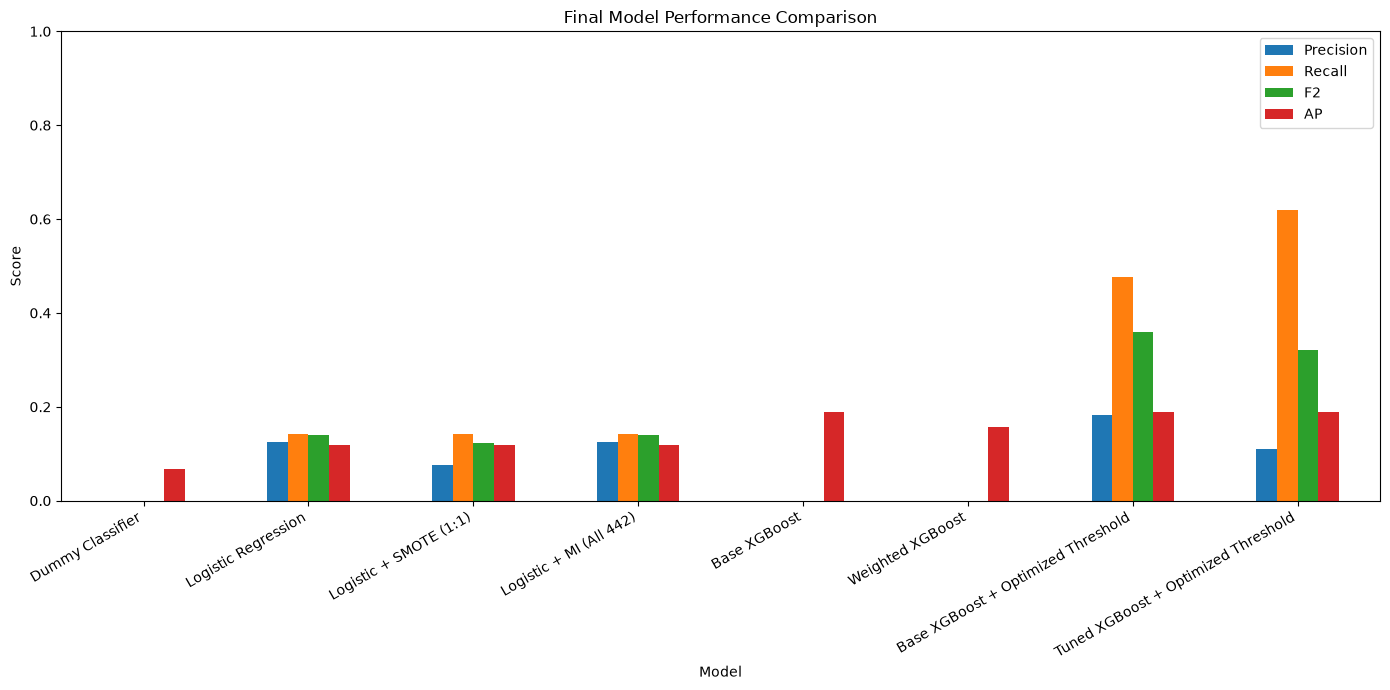

Saved to: ..\results\figures\final_model_metric_comparison.png


In [8]:
comparison_metrics = [
    "Precision",
    "Recall",
    "F2",
    "AP"
]

fixed_split_results.set_index(
    "Model"
)[
    comparison_metrics
].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.ylabel("Score")

plt.title(
    "Final Model Performance Comparison"
)

plt.ylim(0, 1)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

FINAL_METRIC_FIGURE = Path(
    "../results/figures/"
    "final_model_metric_comparison.png"
)

plt.savefig(
    FINAL_METRIC_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved to:",
    FINAL_METRIC_FIGURE
)

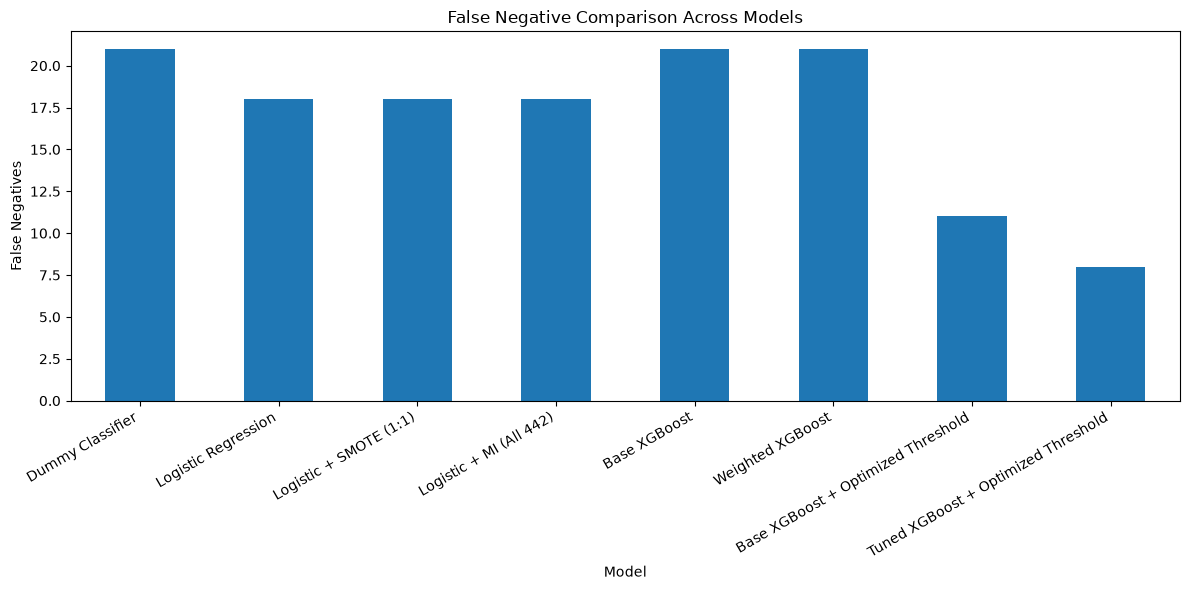

In [9]:
fn_df = (
    fixed_split_results[
        [
            "Model",
            "FN"
        ]
    ]
    .set_index("Model")
)

fn_df.plot(
    kind="bar",
    figsize=(12, 6),
    legend=False
)

plt.ylabel(
    "False Negatives"
)

plt.title(
    "False Negative Comparison Across Models"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

FINAL_FN_FIGURE = Path(
    "../results/figures/"
    "final_false_negative_comparison.png"
)

plt.savefig(
    FINAL_FN_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. False Positive와 False Negative Trade-off

Fail Recall을 높이기 위해 Decision Threshold를 낮추면
False Negative는 감소할 수 있지만,
정상 샘플을 Fail로 판단하는 False Positive가 증가할 수 있다.

따라서 최종 모델 선정에서는
False Negative 하나만 최소화하는 것이 아니라
False Positive 증가량도 함께 고려한다.

In [10]:
error_tradeoff = (
    fixed_split_results[
        [
            "Model",
            "FP",
            "FN",
            "TP",
            "Precision",
            "Recall",
            "F2"
        ]
    ]
    .sort_values(
        "FN"
    )
    .reset_index(drop=True)
)

error_tradeoff.round(4)

,Model,FP,FN,TP,Precision,Recall,F2
0,Tuned XGBoost + Optimized Threshold,105,8,13,0.1102,0.6190,0.3218
1,Base XGBoost + Optimized Threshold,45,11,10,0.1818,0.4762,0.3597
2,Logistic Regression,21,18,3,0.1250,0.1429,0.1389
3,Logistic + SMOTE (1:1),36,18,3,0.0769,0.1429,0.1220
4,Logistic + MI (All 442),21,18,3,0.1250,0.1429,0.1389
5,Dummy Classifier,0,21,0,0.0000,0.0000,0.0000
6,Weighted XGBoost,1,21,0,0.0000,0.0000,0.0000
7,Base XGBoost,1,21,0,0.0000,0.0000,0.0000


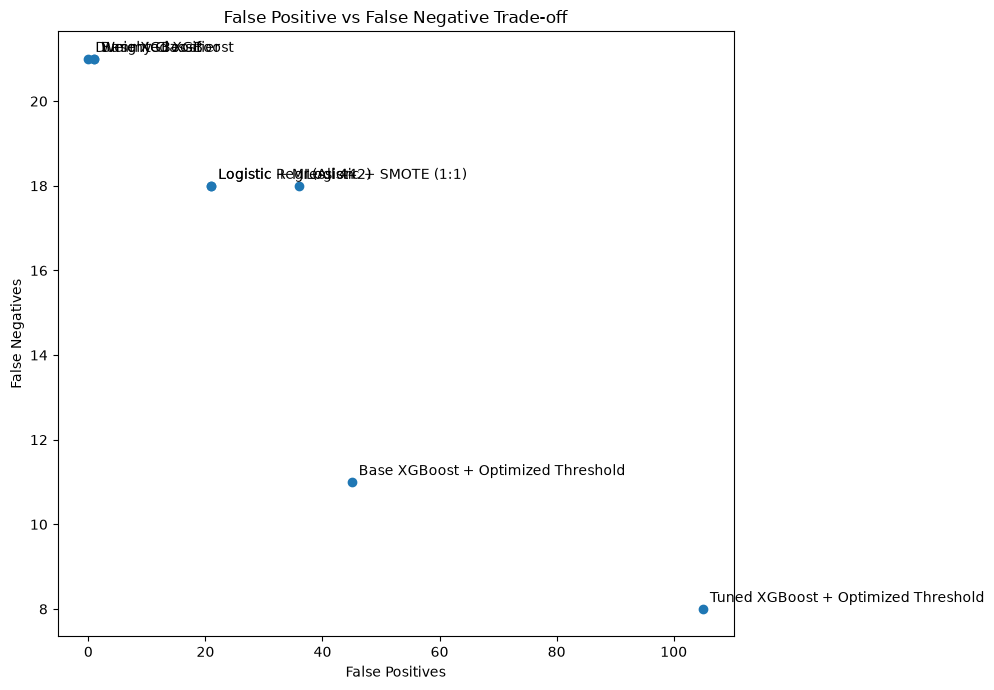

In [11]:
plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    fixed_split_results["FP"],
    fixed_split_results["FN"]
)

for _, row in fixed_split_results.iterrows():

    plt.annotate(
        row["Model"],
        (
            row["FP"],
            row["FN"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel(
    "False Positives"
)

plt.ylabel(
    "False Negatives"
)

plt.title(
    "False Positive vs False Negative Trade-off"
)

plt.tight_layout()

ERROR_TRADEOFF_PATH = Path(
    "../results/figures/"
    "final_fp_fn_tradeoff.png"
)

plt.savefig(
    ERROR_TRADEOFF_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. 최종 모델 후보

Fixed Evaluation Split 결과를 기준으로
두 가지 운영 목적에 따라 최종 후보를 구분한다.

### Candidate A — 균형형 모델

Base XGBoost + Optimized Threshold

해당 모델은 Tuned XGBoost보다 Recall은 낮지만
Precision과 F2-score가 더 높고 False Positive가 훨씬 적다.

### Candidate B — Fail Recall 우선 모델

Tuned XGBoost + Optimized Threshold

해당 모델은 현재까지 가장 높은 Fail Recall과
가장 낮은 False Negative를 기록하였다.

그러나 False Positive가 크게 증가하므로
Fail 미검출 비용이 정상 오탐 비용보다 충분히 큰 환경에서
더 적합한 후보로 해석할 수 있다.

In [12]:
candidate_names = [
    "Base XGBoost + Optimized Threshold",
    "Tuned XGBoost + Optimized Threshold"
]

candidate_comparison = (
    fixed_split_results[
        fixed_split_results[
            "Model"
        ].isin(candidate_names)
    ]
    [
        [
            "Model",
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "F2",
            "AP",
            "ROC-AUC",
            "FP",
            "FN",
            "TP"
        ]
    ]
    .reset_index(drop=True)
)

candidate_comparison.round(4)

,Model,Threshold,Accuracy,Precision,Recall,F1,F2,AP,ROC-AUC,FP,FN,TP
0,Base XGBoost + Optimized Threshold,0.0086,0.8217,0.1818,0.4762,0.2632,0.3597,0.1881,0.7444,45,11,10
1,Tuned XGBoost + Optimized Threshold,0.0742,0.6401,0.1102,0.6190,0.1871,0.3218,0.1891,0.6815,105,8,13


In [13]:
DATA_PATH = Path(
    "../data/processed/uci-secom.csv"
)

df = pd.read_csv(
    DATA_PATH
)

feature_cols = [
    col for col in df.columns
    if col.startswith("feature_")
]

X = df[
    feature_cols
].copy()

y = (
    df["Pass/Fail"]
    .replace({
        -1: 0,
        1: 1
    })
    .astype(int)
)

print(
    "X:",
    X.shape
)

print(
    "y:",
    y.shape
)

X: (1567, 590)
y: (1567,)


In [14]:
from sklearn.model_selection import train_test_split

X_dev, X_fixed_eval, y_dev, y_fixed_eval = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

print(
    "Development data:",
    X_dev.shape
)

print(
    "Fixed evaluation data:",
    X_fixed_eval.shape
)

Development data: (1253, 590)
Fixed evaluation data: (314, 590)


In [15]:
class FeatureQualityFilter(
    BaseEstimator,
    TransformerMixin
):
    def __init__(
        self,
        missing_threshold=40.0
    ):
        self.missing_threshold = (
            missing_threshold
        )

    def fit(self, X, y=None):

        X = pd.DataFrame(
            X
        ).copy()

        missing_ratio = (
            X.isna()
            .mean()
            .mul(100)
        )

        high_missing = (
            missing_ratio[
                missing_ratio
                >= self.missing_threshold
            ]
            .index
            .tolist()
        )

        all_missing = [
            col for col in X.columns
            if X[col].isna().all()
        ]

        single_value = [
            col for col in X.columns
            if X[col].nunique(
                dropna=True
            ) == 1
        ]

        self.features_to_remove_ = sorted(
            set(
                high_missing
                + all_missing
                + single_value
            )
        )

        self.features_to_keep_ = [
            col for col in X.columns
            if col
            not in self.features_to_remove_
        ]

        self.feature_names_in_ = np.array(
            X.columns,
            dtype=object
        )

        return self

    def transform(self, X):

        X = pd.DataFrame(
            X,
            columns=self.feature_names_in_
        ).copy()

        return X[
            self.features_to_keep_
        ]

    def get_feature_names_out(
        self,
        input_features=None
    ):
        return np.array(
            self.features_to_keep_,
            dtype=object
        )

In [16]:
base_xgb_pipeline = Pipeline([
    (
        "quality_filter",
        FeatureQualityFilter(
            missing_threshold=40
        )
    ),
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "model",
        XGBClassifier(
            objective="binary:logistic",
            random_state=42,
            tree_method="hist",
            n_jobs=-1,
            eval_metric="logloss"
        )
    )
])

In [17]:
tuned_xgb_pipeline = Pipeline([
    (
        "quality_filter",
        FeatureQualityFilter(
            missing_threshold=40
        )
    ),
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "model",
        XGBClassifier(
            objective="binary:logistic",

            n_estimators=300,
            max_depth=2,
            learning_rate=0.03,
            min_child_weight=5,
            subsample=0.60,
            colsample_bytree=0.90,
            scale_pos_weight=3.0,

            random_state=42,
            tree_method="hist",
            n_jobs=-1,
            eval_metric="logloss"
        )
    )
])

In [18]:
def select_f2_threshold(
    y_true,
    probabilities,
    beta=2
):
    precision, recall, thresholds = (
        precision_recall_curve(
            y_true,
            probabilities
        )
    )

    precision = precision[:-1]
    recall = recall[:-1]

    fbeta = (
        (1 + beta**2)
        * precision
        * recall
        /
        (
            beta**2 * precision
            + recall
            + 1e-12
        )
    )

    best_index = np.argmax(
        fbeta
    )

    return {
        "threshold":
            thresholds[
                best_index
            ],

        "precision":
            precision[
                best_index
            ],

        "recall":
            recall[
                best_index
            ],

        "f2":
            fbeta[
                best_index
            ]
    }

In [19]:
def evaluate_with_nested_threshold(
    estimator,
    X_data,
    y_data,
    model_name,
    n_splits=5,
    n_repeats=3
):

    outer_cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=42
    )

    fold_results = []

    for fold_number, (
        train_index,
        validation_index
    ) in enumerate(
        outer_cv.split(
            X_data,
            y_data
        ),
        start=1
    ):

        X_outer_train = (
            X_data.iloc[
                train_index
            ]
        )

        y_outer_train = (
            y_data.iloc[
                train_index
            ]
        )

        X_outer_valid = (
            X_data.iloc[
                validation_index
            ]
        )

        y_outer_valid = (
            y_data.iloc[
                validation_index
            ]
        )

        inner_cv = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=(
                1000
                + fold_number
            )
        )

        inner_probabilities = (
            cross_val_predict(
                clone(estimator),
                X_outer_train,
                y_outer_train,
                cv=inner_cv,
                method="predict_proba",
                n_jobs=None
            )[:, 1]
        )

        threshold_info = (
            select_f2_threshold(
                y_outer_train,
                inner_probabilities,
                beta=2
            )
        )

        selected_threshold = (
            threshold_info[
                "threshold"
            ]
        )

        fitted_model = (
            clone(estimator)
        )

        fitted_model.fit(
            X_outer_train,
            y_outer_train
        )

        validation_probabilities = (
            fitted_model
            .predict_proba(
                X_outer_valid
            )[:, 1]
        )

        validation_pred = (
            validation_probabilities
            >= selected_threshold
        ).astype(int)

        tn, fp, fn, tp = (
            confusion_matrix(
                y_outer_valid,
                validation_pred
            )
            .ravel()
        )

        fold_results.append({
            "Model":
                model_name,

            "Fold":
                fold_number,

            "Threshold":
                selected_threshold,

            "Accuracy":
                accuracy_score(
                    y_outer_valid,
                    validation_pred
                ),

            "Precision":
                precision_score(
                    y_outer_valid,
                    validation_pred,
                    zero_division=0
                ),

            "Recall":
                recall_score(
                    y_outer_valid,
                    validation_pred,
                    zero_division=0
                ),

            "F1":
                f1_score(
                    y_outer_valid,
                    validation_pred,
                    zero_division=0
                ),

            "F2":
                fbeta_score(
                    y_outer_valid,
                    validation_pred,
                    beta=2,
                    zero_division=0
                ),

            "AP":
                average_precision_score(
                    y_outer_valid,
                    validation_probabilities
                ),

            "ROC-AUC":
                roc_auc_score(
                    y_outer_valid,
                    validation_probabilities
                ),

            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        })

        print(
            f"{model_name} | "
            f"Fold {fold_number} completed"
        )

    return pd.DataFrame(
        fold_results
    )

In [20]:
base_robustness_results = (
    evaluate_with_nested_threshold(
        estimator=
            base_xgb_pipeline,

        X_data=
            X_dev.reset_index(
                drop=True
            ),

        y_data=
            y_dev.reset_index(
                drop=True
            ),

        model_name=
            "Base XGBoost"
    )
)

Base XGBoost | Fold 1 completed
Base XGBoost | Fold 2 completed
Base XGBoost | Fold 3 completed
Base XGBoost | Fold 4 completed
Base XGBoost | Fold 5 completed
Base XGBoost | Fold 6 completed
Base XGBoost | Fold 7 completed
Base XGBoost | Fold 8 completed
Base XGBoost | Fold 9 completed
Base XGBoost | Fold 10 completed
Base XGBoost | Fold 11 completed
Base XGBoost | Fold 12 completed
Base XGBoost | Fold 13 completed
Base XGBoost | Fold 14 completed
Base XGBoost | Fold 15 completed


In [21]:
tuned_robustness_results = (
    evaluate_with_nested_threshold(
        estimator=
            tuned_xgb_pipeline,

        X_data=
            X_dev.reset_index(
                drop=True
            ),

        y_data=
            y_dev.reset_index(
                drop=True
            ),

        model_name=
            "Tuned XGBoost"
    )
)

Tuned XGBoost | Fold 1 completed
Tuned XGBoost | Fold 2 completed
Tuned XGBoost | Fold 3 completed
Tuned XGBoost | Fold 4 completed
Tuned XGBoost | Fold 5 completed
Tuned XGBoost | Fold 6 completed
Tuned XGBoost | Fold 7 completed
Tuned XGBoost | Fold 8 completed
Tuned XGBoost | Fold 9 completed
Tuned XGBoost | Fold 10 completed
Tuned XGBoost | Fold 11 completed
Tuned XGBoost | Fold 12 completed
Tuned XGBoost | Fold 13 completed
Tuned XGBoost | Fold 14 completed
Tuned XGBoost | Fold 15 completed


In [22]:
robustness_results = pd.concat(
    [
        base_robustness_results,
        tuned_robustness_results
    ],
    ignore_index=True
)

print(
    "Total evaluation folds:",
    len(
        robustness_results
    )
)

robustness_results.head()

Total evaluation folds: 30


,Model,Fold,Threshold,Accuracy,Precision,Recall,F1,F2,AP,ROC-AUC,TN,FP,FN,TP
0,Base XGBoost,1,0.003861,0.673307,0.098765,0.470588,0.163265,0.268456,0.177225,0.596280,161,73,9,8
1,Base XGBoost,2,0.001741,0.545817,0.099174,0.705882,0.173913,0.317460,0.292467,0.719206,125,109,5,12
2,Base XGBoost,3,0.001404,0.541833,0.111111,0.823529,0.195804,0.360825,0.198303,0.696330,122,112,3,14
3,Base XGBoost,4,0.003069,0.680000,0.089744,0.437500,0.148936,0.246479,0.121017,0.670673,163,71,9,7
4,Base XGBoost,5,0.002589,0.624000,0.093750,0.562500,0.160714,0.281250,0.212202,0.651709,147,87,7,9


In [23]:
ROBUSTNESS_FOLD_PATH = Path(
    "../results/metrics/"
    "final_robustness_fold_results.csv"
)

robustness_results.to_csv(
    ROBUSTNESS_FOLD_PATH,
    index=False
)

print(
    "Saved to:",
    ROBUSTNESS_FOLD_PATH
)

Saved to: ..\results\metrics\final_robustness_fold_results.csv


In [25]:
robustness_summary = (
    robustness_results
    .groupby(
        "Model"
    )
    .agg(
        {
            "Threshold": [
                "mean",
                "std"
            ],

            "Precision": [
                "mean",
                "std"
            ],

            "Recall": [
                "mean",
                "std"
            ],

            "F2": [
                "mean",
                "std"
            ],

            "AP": [
                "mean",
                "std"
            ],

            "ROC-AUC": [
                "mean",
                "std"
            ],

            "FN": [
                "mean",
                "std"
            ],

            "FP": [
                "mean",
                "std"
            ]
        }
    )
)

robustness_summary.round(4)

Threshold         Precision          Recall              F2  \
                   mean     std      mean     std    mean     std    mean   
Model                                                                       
Base XGBoost     0.0031  0.0022    0.1029  0.0199  0.5936  0.1821  0.2954   
Tuned XGBoost    0.0705  0.0208    0.1100  0.0195  0.6353  0.1546  0.3175   

                           AP         ROC-AUC              FN          \
                  std    mean     std    mean     std    mean     std   
Model                                                                   
Base XGBoost   0.0536  0.1770  0.0649  0.6653  0.0648  6.7333  3.0111   
Tuned XGBoost  0.0423  0.1885  0.0616  0.6931  0.0580  6.0667  2.6040   

                    FP           
                  mean      std  
Model                            
Base XGBoost   88.0000  29.1499  
Tuned XGBoost  88.9333  32.2257

In [26]:
robustness_summary_flat = (
    robustness_results
    .groupby("Model")
    .agg(
        Threshold_Mean=(
            "Threshold",
            "mean"
        ),
        Threshold_Std=(
            "Threshold",
            "std"
        ),

        Precision_Mean=(
            "Precision",
            "mean"
        ),
        Precision_Std=(
            "Precision",
            "std"
        ),

        Recall_Mean=(
            "Recall",
            "mean"
        ),
        Recall_Std=(
            "Recall",
            "std"
        ),

        F2_Mean=(
            "F2",
            "mean"
        ),
        F2_Std=(
            "F2",
            "std"
        ),

        AP_Mean=(
            "AP",
            "mean"
        ),
        AP_Std=(
            "AP",
            "std"
        ),

        ROC_AUC_Mean=(
            "ROC-AUC",
            "mean"
        ),
        ROC_AUC_Std=(
            "ROC-AUC",
            "std"
        ),

        FN_Mean=(
            "FN",
            "mean"
        ),
        FN_Std=(
            "FN",
            "std"
        ),

        FP_Mean=(
            "FP",
            "mean"
        ),
        FP_Std=(
            "FP",
            "std"
        )
    )
    .reset_index()
)

robustness_summary_flat.round(4)

,Model,Threshold_Mean,Threshold_Std,Precision_Mean,Precision_Std,Recall_Mean,Recall_Std,F2_Mean,F2_Std,AP_Mean,AP_Std,ROC_AUC_Mean,ROC_AUC_Std,FN_Mean,FN_Std,FP_Mean,FP_Std
0,Base XGBoost,0.0031,0.0022,0.1029,0.0199,0.5936,0.1821,0.2954,0.0536,0.1770,0.0649,0.6653,0.0648,6.7333,3.0111,88.0000,29.1499
1,Tuned XGBoost,0.0705,0.0208,0.1100,0.0195,0.6353,0.1546,0.3175,0.0423,0.1885,0.0616,0.6931,0.0580,6.0667,2.6040,88.9333,32.2257


In [27]:
ROBUSTNESS_SUMMARY_PATH = Path(
    "../results/metrics/"
    "final_robustness_summary.csv"
)

robustness_summary_flat.to_csv(
    ROBUSTNESS_SUMMARY_PATH,
    index=False
)

print(
    "Saved to:",
    ROBUSTNESS_SUMMARY_PATH
)

Saved to: ..\results\metrics\final_robustness_summary.csv


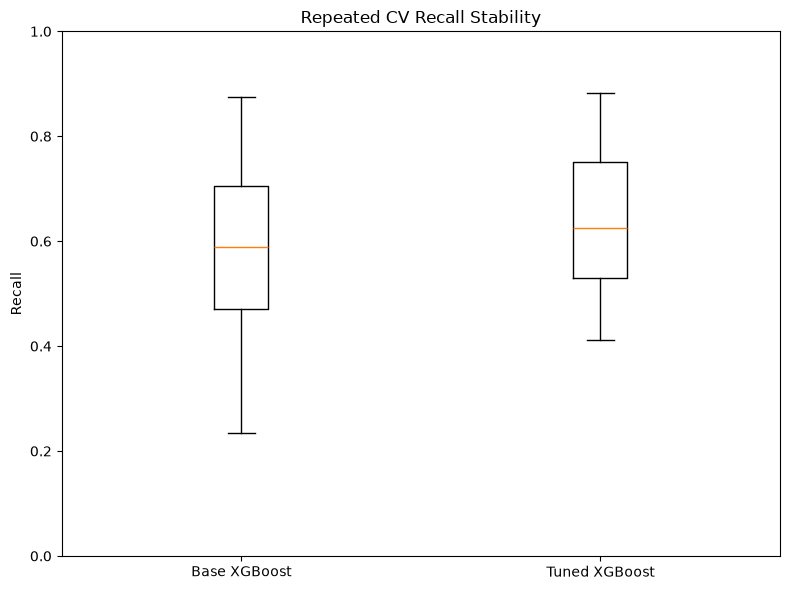

In [28]:
base_recall = (
    robustness_results[
        robustness_results["Model"]
        == "Base XGBoost"
    ]["Recall"]
)

tuned_recall = (
    robustness_results[
        robustness_results["Model"]
        == "Tuned XGBoost"
    ]["Recall"]
)

plt.figure(
    figsize=(8, 6)
)

plt.boxplot(
    [
        base_recall,
        tuned_recall
    ],
    tick_labels=[
        "Base XGBoost",
        "Tuned XGBoost"
    ]
)

plt.ylabel(
    "Recall"
)

plt.title(
    "Repeated CV Recall Stability"
)

plt.ylim(
    0,
    1
)

plt.tight_layout()

ROBUSTNESS_RECALL_PATH = Path(
    "../results/figures/"
    "robustness_recall_boxplot.png"
)

plt.savefig(
    ROBUSTNESS_RECALL_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

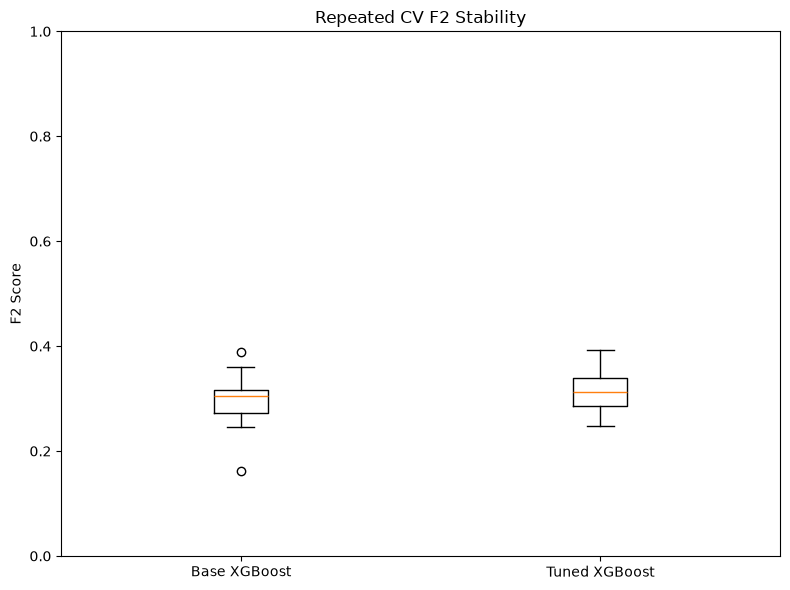

In [29]:
base_f2 = (
    robustness_results[
        robustness_results["Model"]
        == "Base XGBoost"
    ]["F2"]
)

tuned_f2 = (
    robustness_results[
        robustness_results["Model"]
        == "Tuned XGBoost"
    ]["F2"]
)

plt.figure(
    figsize=(8, 6)
)

plt.boxplot(
    [
        base_f2,
        tuned_f2
    ],
    tick_labels=[
        "Base XGBoost",
        "Tuned XGBoost"
    ]
)

plt.ylabel(
    "F2 Score"
)

plt.title(
    "Repeated CV F2 Stability"
)

plt.ylim(
    0,
    1
)

plt.tight_layout()

ROBUSTNESS_F2_PATH = Path(
    "../results/figures/"
    "robustness_f2_boxplot.png"
)

plt.savefig(
    ROBUSTNESS_F2_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

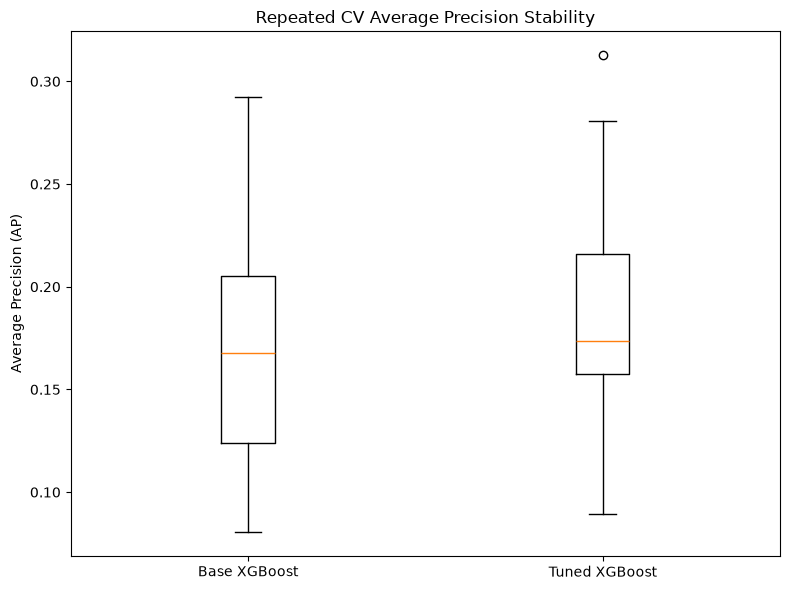

In [30]:
base_ap = (
    robustness_results[
        robustness_results["Model"]
        == "Base XGBoost"
    ]["AP"]
)

tuned_ap = (
    robustness_results[
        robustness_results["Model"]
        == "Tuned XGBoost"
    ]["AP"]
)

plt.figure(
    figsize=(8, 6)
)

plt.boxplot(
    [
        base_ap,
        tuned_ap
    ],
    tick_labels=[
        "Base XGBoost",
        "Tuned XGBoost"
    ]
)

plt.ylabel(
    "Average Precision (AP)"
)

plt.title(
    "Repeated CV Average Precision Stability"
)

plt.tight_layout()

ROBUSTNESS_AP_PATH = Path(
    "../results/figures/"
    "robustness_ap_boxplot.png"
)

plt.savefig(
    ROBUSTNESS_AP_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Robustness Check 해석 원칙

Fixed Evaluation Split의 단일 결과만으로
최종 모델의 일반화 성능을 단정하지 않는다.

두 최종 후보에 대해 반복적인 Stratified Cross Validation을 수행하고,
각 Outer Training Fold 내부에서 별도의 OOF 예측 확률을 이용하여
Decision Threshold를 다시 선택하였다.

이를 통해 데이터 분할이 변경될 때 다음 항목의 변동성을 확인한다.

- Decision Threshold
- Precision
- Recall
- F2-score
- Average Precision
- ROC-AUC
- False Negative
- False Positive

본 Robustness Check는 이미 선정된 모델 구성의
성능 안정성을 확인하기 위한 사후 분석이다.

Hyperparameter Search 자체까지 Outer Fold마다 다시 수행하는
완전한 Nested Hyperparameter Cross Validation은 아니므로,
독립적인 최종 일반화 성능 추정치라고 과도하게 해석하지 않는다.

## 6. 최종 모델 선정 및 프로젝트 결론

본 프로젝트에서는 SECOM 반도체 제조 데이터를 이용하여
다양한 방법으로 Fail 예측 성능을 개선하였다.

최종적으로 Base XGBoost와 Tuned XGBoost를 주요 후보로 선정하고,
Fixed Evaluation Split 결과뿐만 아니라
Repeated Stratified Cross Validation 기반 Robustness Check를 이용하여
두 모델의 성능 안정성을 비교하였다.


### 1. Fixed Evaluation Split 결과

Base XGBoost + Optimized Threshold의 성능은 다음과 같았다.

- Precision: 18.18%
- Recall: 47.62%
- F2-score: 35.97%
- Average Precision: 0.1881
- False Negative: 11개
- False Positive: 45개
- True Positive: 10개

Tuned XGBoost + Optimized Threshold의 성능은 다음과 같았다.

- Precision: 11.02%
- Recall: 61.90%
- F2-score: 32.18%
- Average Precision: 0.1891
- False Negative: 8개
- False Positive: 105개
- True Positive: 13개

단일 Fixed Evaluation Split에서는
Base XGBoost가 더 높은 Precision과 F2-score,
그리고 더 적은 False Positive를 기록하였다.

반면 Tuned XGBoost는 더 높은 Fail Recall을 기록하고
False Negative를 11개에서 8개로 감소시켰다.


### 2. Repeated Cross Validation 결과

단일 데이터 분할에 따른 성능 변동성을 확인하기 위해
Development Data에서 5-Fold Stratified Cross Validation을
3회 반복하여 총 15개의 Outer Validation 결과를 비교하였다.

각 Outer Training Fold 내부에서는 별도의 OOF 예측 확률을 생성하여
F2-score 기준 Decision Threshold를 다시 선택하였다.

Base XGBoost의 평균 성능은 다음과 같다.

- Precision: 10.29% ± 1.99%p
- Recall: 59.36% ± 18.21%p
- F2-score: 0.2954 ± 0.0536
- Average Precision: 0.1770 ± 0.0649
- ROC-AUC: 0.6653 ± 0.0648
- 평균 False Negative: 6.73개
- 평균 False Positive: 88.00개

Tuned XGBoost의 평균 성능은 다음과 같다.

- Precision: 11.00% ± 1.95%p
- Recall: 63.53% ± 15.46%p
- F2-score: 0.3175 ± 0.0423
- Average Precision: 0.1885 ± 0.0616
- ROC-AUC: 0.6931 ± 0.0580
- 평균 False Negative: 6.07개
- 평균 False Positive: 88.93개


### 3. Robustness Check 해석

Fixed Evaluation Split에서는
Base XGBoost가 F2-score와 False Positive 측면에서 더 우수하였다.

그러나 Repeated Cross Validation에서는
Tuned XGBoost가 다음 지표에서 평균적으로 더 높은 성능을 기록하였다.

- Precision
- Recall
- F2-score
- Average Precision
- ROC-AUC

특히 Fail Recall은:

- Base XGBoost: 59.36%
- Tuned XGBoost: 63.53%

로 Tuned XGBoost가 더 높았다.

F2-score 역시:

- Base XGBoost: 0.2954
- Tuned XGBoost: 0.3175

로 Tuned XGBoost가 더 높은 평균 성능을 기록하였다.

또한 Recall, F2-score, Average Precision 및 ROC-AUC의
표준편차도 Tuned XGBoost에서 상대적으로 작게 나타났다.

이는 Tuned XGBoost가 여러 데이터 분할에서
상대적으로 더 안정적인 성능을 보였음을 시사한다.


### 4. False Positive Trade-off 재평가

Fixed Evaluation Split에서는
Base XGBoost의 False Positive가 45개,
Tuned XGBoost의 False Positive가 105개로 큰 차이를 보였다.

그러나 Repeated Cross Validation의 평균 False Positive는:

- Base XGBoost: 88.00개
- Tuned XGBoost: 88.93개

로 거의 유사하였다.

따라서 단일 Fixed Evaluation Split에서 관찰된
큰 False Positive 차이가 모든 데이터 분할에서
일관되게 반복되는 현상이라고 판단하기는 어렵다.

이 결과는 불균형 데이터에서 단일 Holdout 결과만으로
모델의 특성을 일반화하는 데 주의가 필요함을 보여준다.


### 5. 최종 모델 후보 선정

Fixed Evaluation Split과 Repeated Cross Validation 결과를
종합적으로 고려하여 본 프로젝트에서는

**Tuned XGBoost + Optimized Decision Threshold**

를 최종 모델 후보로 선정한다.

주요 선정 근거는 다음과 같다.

1. Repeated CV에서 가장 높은 평균 Fail Recall을 기록하였다.
2. Repeated CV에서 가장 높은 평균 F2-score를 기록하였다.
3. Average Precision과 ROC-AUC도 Base XGBoost보다 높았다.
4. 평균 False Negative가 더 적었다.
5. 주요 평가 지표의 변동성이 상대적으로 낮았다.

다만 실제 제조 환경에서 모델을 적용하기 위해서는
Decision Threshold를 고정된 절대값으로 간주해서는 안 된다.

Fail 제품의 미검출 비용과 정상 제품의 오탐 비용,
추가 검사 Capacity 및 실제 공정 요구사항을 고려하여
운영 Threshold를 결정해야 한다.


## 7. 프로젝트 전체 분석 결론

본 프로젝트에서는 SECOM 데이터의 심각한 클래스 불균형과
높은 차원의 센서 데이터를 대상으로
단계적인 모델 개선 실험을 수행하였다.

초기 Logistic Regression은 Fail Recall 14.29%에 그쳤으며,
SMOTE 1:1 및 Mutual Information 기반 Feature Selection만으로는
의미 있는 개선을 얻지 못하였다.

XGBoost는 기본 Threshold 0.5에서 Fail을 검출하지 못했지만,
Average Precision과 ROC-AUC에서는 Logistic Regression보다
높은 확률 순위 성능을 보였다.

이를 기반으로 Training Data 내부의 OOF 예측 확률을 이용하여
Decision Threshold를 최적화한 결과,
Base XGBoost의 Fail Recall을 47.62%까지 개선하였다.

이후 Randomized Search 기반 Hyperparameter Tuning을 수행한 결과
Cross-Validated Average Precision 0.2111을 기록하는
XGBoost 조합을 선택하였다.

Tuned 모델에 대해 Threshold를 다시 최적화한 결과
Fixed Evaluation Split에서 Fail Recall 61.90%,
False Negative 8개를 기록하였다.

마지막으로 Repeated Stratified Cross Validation을 이용한
Robustness Check에서도 Tuned XGBoost가
Base XGBoost보다 평균 Recall, F2-score,
Average Precision 및 ROC-AUC에서 높은 성능을 기록하였다.

따라서 본 프로젝트에서는 단순 Accuracy 최대화보다
Fail 검출과 False Negative 감소를 중심으로 모델을 평가하였으며,
불균형 제조 데이터에서

- 모델 구조
- 클래스 가중치
- Feature Selection
- Decision Threshold
- Hyperparameter Tuning

이 각각 예측 성능에 미치는 영향을 단계적으로 분석하였다.


## 8. 분석의 한계

본 분석에는 다음과 같은 한계가 존재한다.

첫째, SECOM 데이터의 센서 Feature가 익명화되어 있어
중요 Feature를 실제 공정 Parameter나 설비 조건과 직접 연결할 수 없다.

따라서 Feature Importance를 물리적인 불량 Root Cause로
해석할 수 없다.

둘째, Fail 샘플 수가 전체 데이터에 비해 매우 적기 때문에
데이터 분할에 따른 평가 지표의 변동성이 존재한다.

셋째, Fixed Evaluation Split은 프로젝트 개발 과정에서
여러 차례 성능 확인에 사용되었으므로
완전히 독립적인 Untouched Final Test Set으로 간주하지 않는다.

이를 보완하기 위해 Repeated Cross Validation 기반
Robustness Check를 추가하였다.

넷째, Robustness Check에서는 이미 선택된 Hyperparameter를 사용하였으며,
각 Outer Fold에서 Hyperparameter Search 전체를 다시 수행하는
완전한 Nested Hyperparameter Cross Validation은 수행하지 않았다.

따라서 본 결과는 최종적인 산업 적용 성능 추정치라기보다
모델 개발 및 비교를 위한 분석 결과로 해석한다.


## 9. 향후 개선 방향

향후 실제 제조 데이터가 제공된다면 다음 분석으로 확장할 수 있다.

- Lot / Wafer / Chamber 단위 Group-aware Validation
- 시간 순서를 고려한 Temporal Validation
- 모델 Probability Calibration
- 공정 비용 기반 Cost-sensitive Threshold Optimization
- SHAP 기반 Feature Contribution 분석
- 설비 및 Recipe 정보와 Feature Importance 연계
- Drift Monitoring
- 외부 생산 Lot을 이용한 독립적인 Validation

이를 통해 단순 Fail Prediction을 넘어
공정 이상 탐지와 Root Cause Analysis를 지원하는
실제 제조 데이터 분석 Pipeline으로 확장할 수 있다.